Optimization refers to the process of adjusting a model to get the best performance possible on the training data (the learning in machine learning), whereas generalization refers to how well the trained model performs on data it has never seen before.

Overfitting - it’s beginning to learn patterns that are specific to the training data but that are misleading or irrelevant when it comes to new data.

If you’ve only ever seen two orange tabby cats in your life, and they both happened to be terribly antisocial, you might infer that orange tabby cats are generally likely to be antisocial. That’s overfitting: if you had been exposed to a wider variety of cats, including more orange ones, you’d have learned that cat color is not well correlated with character.

Sweet spot

<img src="./images/DL_concepts_1.png" width=1000/>

Weirdness in dataset

<img src="./images/DL_concepts_2.png" width=1000/>

Mislabelled data

<img src="./images/DL_concepts_3.png" width=1000/>

Effect of overfitting on test data

<img src="./images/DL_concepts_5.png" width=1000/>


### Effect of noise on the original data

In [1]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

In [2]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8657 - loss: 0.4461 - val_accuracy: 0.9153 - val_loss: 0.2823
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9327 - loss: 0.2265 - val_accuracy: 0.9413 - val_loss: 0.2002
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9548 - loss: 0.1547 - val_accuracy: 0.9350 - val_loss: 0.2102
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9666 - loss: 0.1146 - val_accuracy: 0.9470 - val_loss: 0.1732
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.0830 - val_accuracy: 0.9597 - val_loss: 0.1359
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9830 - loss: 0.0596 - val_accuracy: 0.9545 - val_loss: 0.1488
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.0431 - val_accuracy: 0.9628 - val_loss: 0.1283
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0293 - val_accuracy: 0.

<img src="./images/DL_concepts_4.png" width=1000/>

### Evaluating the model

Evaluating a model always boils down to splitting the available data into three sets: training, validation, and test. 

You train on the training data and evaluate your model on the validation data. 

Once your model is ready for prime time, you test it one final time on the test data, which is meant to be as similar as possible to production data. Then you can deploy the model in production.

Every time you tune a hyperparameter of your model based on the model’s performance on the validation set, some information about the validation data leaks into the model. 

If you do this only once, for one parameter, then very few bits of information will leak, and your validation set will remain reliable to evaluate the model. 

But if you repeat this many times — running one experiment, evaluating on the validation set, and modifying your model as a result — then you’ll leak an increasingly significant amount of information about the validation set into the model.

At the end of the day, you’ll end up with a model that performs artificially well on the validation data because that’s what you optimized it for. 

You care about performance on completely new data, not the validation data, so you need to use a completely different, never-before-seen dataset to evaluate the model: the test dataset. 

Your model shouldn’t have had access to any information about the test set, even indirectly. If anything about the model has been tuned based on test set performance, then your measure of generalization will be flawed.

Strategies on validation :

1)  Maintaining a hold-out validation set  — The way to go when you have plenty of data.

2)  Doing K-fold cross-validation  — The right choice when you have too few samples for hold-out validation to be reliable.

3)  Doing iterated K-fold validation  — For performing highly accurate model evaluation when little data is available.

1)  Data representativeness  — 

You want both your training set and test set to be representative of the data at hand. 

For instance, if you’re trying to classify images of digits, and you’re starting from an array of samples where the samples are ordered by their class, taking the first 80% of the array as your training set and the remaining 20% as your test set will result in your training set containing only classes 0–7, whereas your test set contains only classes 8–9. 

This seems like a ridiculous mistake, but it’s surprisingly common. For this reason, you usually should randomly shuffle your data before splitting it into training and test sets.


2) The arrow of time  — 

If you’re trying to predict the future given the past (for example, tomorrow’s weather, stock movements, and so on), you should not randomly shuffle your data before splitting it because doing so will create a temporal leak.

Your model will effectively be trained on data from the future. 

In such situations, you should always make sure all data in your test set is posterior to the data in the training set.


3)  Redundancy in your data  — 

If some data points in your data appear twice (fairly common with real-world data), then shuffling the data and splitting it into a training set and a validation set will result in redundancy between the training and validation sets. 

In effect, you’ll be testing on part of your training data, which is the worst thing you can do! Make sure your training set and validation set are disjoint.


### Importance of hyperparameters 
##### 1) Learning rate

In [3]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3341 - loss: 864.5418 - val_accuracy: 0.2344 - val_loss: 2.2506
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2279 - loss: 3.2659 - val_accuracy: 0.2194 - val_loss: 2.2902
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2215 - loss: 2.5621 - val_accuracy: 0.1911 - val_loss: 2.2199
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2177 - loss: 2.4705 - val_accuracy: 0.1822 - val_loss: 2.2175
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1943 - loss: 2.4524 - val_accuracy: 0.1966 - val_loss: 2.2786
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2038 - loss: 2.3311 - val_accuracy: 0.2131 - val_loss: 2.1236
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2222 - loss: 2.2995 - val_accuracy: 0.2340 - val_loss: 2.2320
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2142 - loss: 2.4137 - val_accuracy: 

As you see from above, it's a starting problem - the "bike" (training process) doesn't start

In [4]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9138 - loss: 0.3481 - val_accuracy: 0.9611 - val_loss: 0.1398
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9640 - loss: 0.1291 - val_accuracy: 0.9668 - val_loss: 0.1282
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9739 - loss: 0.0955 - val_accuracy: 0.9568 - val_loss: 0.1877
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9790 - loss: 0.0811 - val_accuracy: 0.9567 - val_loss: 0.1894
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.0685 - val_accuracy: 0.9728 - val_loss: 0.1490
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9847 - loss: 0.0617 - val_accuracy: 0.9703 - val_loss: 0.1890
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9874 - loss: 0.0539 - val_accuracy: 0.9701 - val_loss: 0.2047
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9877 - loss: 0.0532 - val_accuracy: 0.

Wow, capping the learning rate gives you astounding results !

##### Try these techniques to have a better training for your model :

1)  Lowering or increasing the learning rate. A learning rate that is too high may lead to updates that vastly overshoot a proper fit, like in the previous example, and a learning rate that is too low may make training so slow that it appears to stall.

2)  Increasing the batch size. A batch with more samples will lead to gradients that are more informative and less noisy (lower variance).

##### 2) Epochs 

In [5]:
## A simple Logistic regression

model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=40, batch_size=128, validation_split=0.2
)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - accuracy: 0.8365 - loss: 0.6709 - val_accuracy: 0.9066 - val_loss: 0.3603
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - accuracy: 0.9031 - loss: 0.3530 - val_accuracy: 0.9162 - val_loss: 0.3089
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.9113 - loss: 0.3174 - val_accuracy: 0.9174 - val_loss: 0.2924
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.9157 - loss: 0.3017 - val_accuracy: 0.9221 - val_loss: 0.2832
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - accuracy: 0.9185 - loss: 0.2921 - val_accuracy: 0.9222 - val_loss: 0.2795
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - accuracy: 0.9200 - loss: 0.2856 - val_accuracy: 0.9242 - val_loss: 0.2744
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - accuracy: 0.9217 - loss: 0.2804 - val_accuracy: 0.9247 - val_loss: 0.2714
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - accuracy: 0.9229 - loss: 0.2765 - 

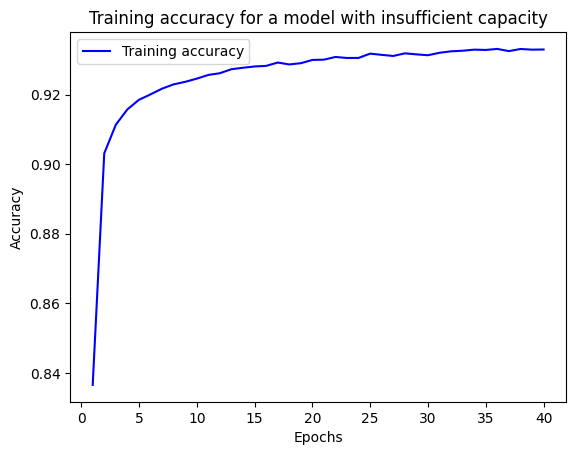

In [9]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["accuracy"]
epochs = range(1, 41)
plt.plot(epochs, val_loss, "b-", label="Training accuracy")
plt.title("Training accuracy for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [8]:
history_small_model.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

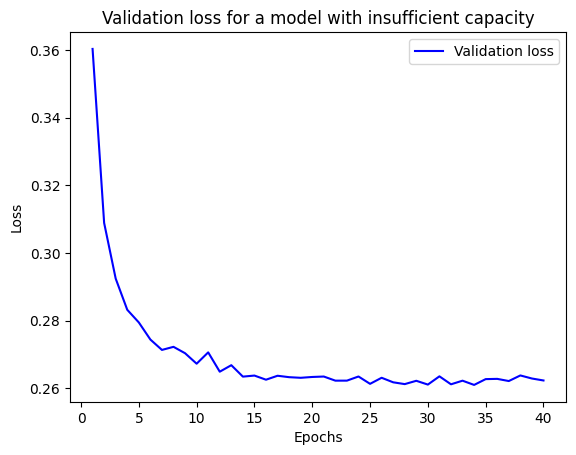

In [6]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 41)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

This curve is dangerous. It may seem correct initially but if you take a closer look, you observe that the validation loss gets stuck in 0.26.

You can fit, but you can’t clearly overfit, even after many iterations over the training data.

In [10]:
############## Let's add more layers ##############

model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9020 - loss: 0.3366 - val_accuracy: 0.9504 - val_loss: 0.1704
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - accuracy: 0.9568 - loss: 0.1438 - val_accuracy: 0.9608 - val_loss: 0.1308
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.9699 - loss: 0.0990 - val_accuracy: 0.9672 - val_loss: 0.1074
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.9768 - loss: 0.0758 - val_accuracy: 0.9718 - val_loss: 0.0964
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9825 - loss: 0.0574 - val_accuracy: 0.9700 - val_loss: 0.1007
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9856 - loss: 0.0461 - val_accuracy: 0.9743 - val_loss: 0.0928
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9888 - loss: 0.0370 - val_accuracy: 0.9730 - val_loss: 0.0944
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.9910 - loss: 0.0293 - val_accu

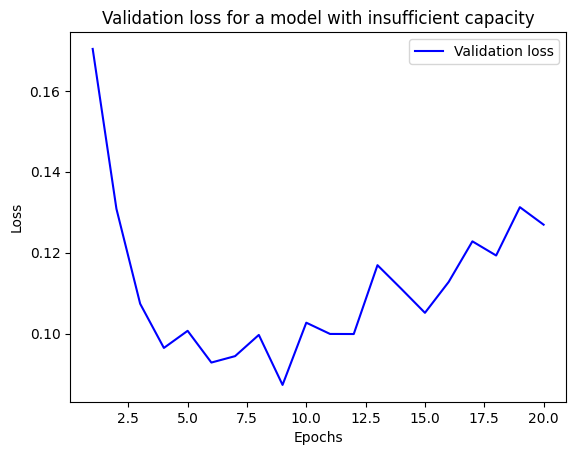

In [11]:
import matplotlib.pyplot as plt

val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training curves now look exactly like they should: the model fits fast and starts overfitting after eight epochs.

In [12]:
############## Let's add EVEN more layers ##############

model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    # When training larger models, you can reduce the batch size to
    # limit memory consumption.
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9262 - loss: 0.2560 - val_accuracy: 0.9680 - val_loss: 0.1266
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9690 - loss: 0.1151 - val_accuracy: 0.9707 - val_loss: 0.1316
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9786 - loss: 0.0876 - val_accuracy: 0.9723 - val_loss: 0.1422
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9838 - loss: 0.0669 - val_accuracy: 0.9721 - val_loss: 0.1607
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9869 - loss: 0.0546 - val_accuracy: 0.9744 - val_loss: 0.1646
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9893 - loss: 0.0446 - val_accuracy: 0.9771 - val_loss: 0.1582
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9918 - loss: 0.0331 - val_accuracy: 0.9798 - val_loss: 0.1694
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9935 - 

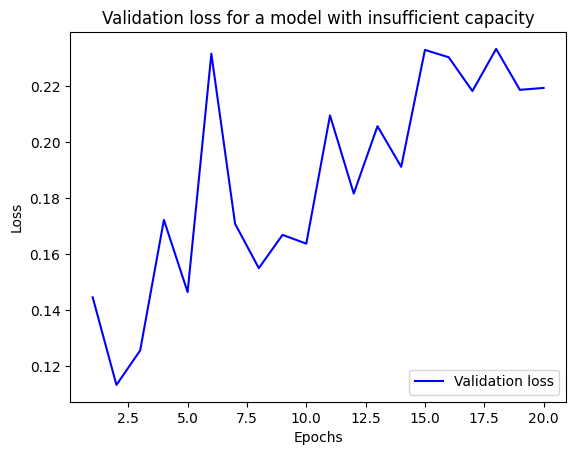

In [10]:
import matplotlib.pyplot as plt

val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Importance of dataset

1)  Make sure you have enough data. Remember that you need a dense sampling of the input-cross-output space. More data will yield a better model. Sometimes, problems that seem impossible at first become solvable with a larger dataset.

2)  Minimize labeling errors — visualize your inputs to check for anomalies, and proofread your labels.

3)  Clean your data and deal with missing values.

4)  If you have many features and you aren’t sure which ones are actually useful, do feature selection.

### Importance of feature engineering

<img src="./images/DL_concepts_6.png" width=1000/>


That’s the essence of feature engineering: making a problem easier by expressing it in a simpler way.

Before deep learning, feature engineering used to be the most important part of the machine learning workflow because classical shallow algorithms didn’t have hypothesis spaces rich enough to learn useful features by themselves. 

The way you presented the data to the algorithm was absolutely critical to its success. 

For instance, before convolutional neural networks became successful on the MNIST digit-classification problem, solutions were typically based on hardcoded features such as the number of loops in a digit image, the height of each digit in an image, a histogram of pixel values, and so on.

Fortunately, modern deep learning removes the need for most feature engineering because neural networks are capable of automatically extracting useful features from raw data. Does this mean you don’t have to worry about feature engineering as long as you’re using deep neural networks? No, for two reasons:

1)  Good features still allow you to solve problems more elegantly while using fewer resources. For instance, it would be ridiculous to solve the problem of reading a clock face using a convolutional neural network.

2)  Good features let you solve a problem with far less data. The ability of deep-learning models to learn features on their own relies on having lots of training data available; if you have only a few samples, then the information value in their features becomes critical.


# Ways to reduce overfitting

### 1) Weight regularization

Simpler models are less likely to overfit than complex ones.

Common way to mitigate overfitting is to put constraints on the complexity of a model by forcing its weights to take only small values, which makes the distribution of weight values more regular.

This is called weight regularization, and it’s done by adding to the loss function of the model a cost associated with having large weights. This cost comes in two flavors:

L1 regularization  — The cost added is proportional to the absolute value of the weight coefficients (the L1 norm of the weights).

L2 regularization — The cost added is proportional to the square of the value of the weight coefficients (the L2 norm of the weights). L2 regularization is also called weight decay in the context of neural networks.

l2(0.002) means every coefficient in the weight matrix of the layer will add 0.002 * weight_coefficient_value ** 2 to the total loss of the model.

E.g. : 0.1 => 0.002 × (0.1²) = 0.00002  
5.0 => 0.002 × (25) = 0.05

In [13]:
from keras.regularizers import l2

from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7813 - loss: 0.6188 - val_accuracy: 0.8079 - val_loss: 0.5231
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8892 - loss: 0.4245 - val_accuracy: 0.8815 - val_loss: 0.4022
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9099 - loss: 0.3472 - val_accuracy: 0.8861 - val_loss: 0.3725
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9211 - loss: 0.3076 - val_accuracy: 0.8825 - val_loss: 0.3730
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9291 - loss: 0.2855 - val_accuracy: 0.8892 - val_loss: 0.3569
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9349 - loss: 0.2681 - val_accuracy: 0.8681 - val_loss: 0.4006
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9419 - loss: 0.2555 - val_accuracy: 0.8829 - val_loss: 0.3669
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9400 - loss: 0.2534 - val_accuracy: 0.8850 - val_loss

<img src="./images/DL_concepts_7.png" width=1000/>


### 2)  Adding a DropOut

<img src="./images/DL_concepts_8.png" width=1000/>


In [17]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6171 - loss: 0.6429 - val_accuracy: 0.8320 - val_loss: 0.5394
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7394 - loss: 0.5336 - val_accuracy: 0.8737 - val_loss: 0.4309
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - loss: 0.4612 - val_accuracy: 0.8813 - val_loss: 0.3653
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8384 - loss: 0.3996 - val_accuracy: 0.8783 - val_loss: 0.3278
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8631 - loss: 0.3589 - val_accuracy: 0.8857 - val_loss: 0.2998
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8899 - loss: 0.3138 - val_accuracy: 0.8937 - val_loss: 0.2794
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9009 - loss: 0.2764 - val_accuracy: 0.8772 - val_loss: 0.3042
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9131 - loss: 0.2516 - val_accuracy: 0.8933 - val_loss:

<img src="./images/DL_concepts_9.png" width=1000/>


To recap, these are the most common ways to maximize generalization and prevent overfitting in neural networks:

<pre>
    1)  Getting more training data, or better training data
    2)  Developing better features
    3)  Optimized capacity of the model
    4)  Adding weight regularization (for smaller models)
    5)  Adding dropout
</pre>

### Few pointers and tips

1)  Training data should be ALWAYS representative of the production data

Use case - Suppose you’re developing an app where users can take pictures of a dish to find out its name. You train a model using pictures from an image-sharing social network that’s popular with foodies. Come deployment time, and feedback from angry users starts rolling in: your app gets the answer wrong 8 times out of 10. What’s going on? Your accuracy on the test set was well over 90%! A quick look at user-uploaded data reveals that mobile picture uploads of random dishes from random restaurants taken with random smartphones look nothing like the professional-quality, well-lit, appetizing pictures you trained the model on: your training data wasn’t representative of the production data.

A particularly insidious and common case of nonrepresentative data is sampling bias.

2)  Concept drift - Concept drift occurs when the properties of the production data change over time, causing model accuracy to gradually decay.

Use case - A music recommendation engine trained in the year 2013 may not be very effective today. Likewise, the IMDB dataset you worked with was collected in 2011, and a model trained on it would likely not perform as well on reviews from 2020 compared to reviews from 2012, as vocabulary, expressions, and movie genres evolve over time. Concept drift is particularly acute in adversarial contexts like credit card fraud detection, where fraud patterns change practically every day. 

Dealing with fast concept drift requires constant data collection, annotation, and model retraining.

Using machine learning trained on past data to predict the future is making the assumption that the future will behave like the past. That often isn’t the case.

3)  Check for target leaking — the presence of features in your data that provide information about the targets that may not be available in production. If you’re training a model on medical records to predict whether someone will be treated for cancer in the future, and the records include the feature “This person has been diagnosed with cancer,” then your targets are being artificially leaked into your data.

4)  Missing values check - Note that if you’re expecting missing categorical features in the test data, but the network was trained on data without any missing values, the network won’t have learned to ignore missing values! In this situation, you should artificially generate training samples with missing entries: copy some training samples several times, and drop some of the categorical features that you expect are likely to be missing in the test data.



5. Generalization - Try to develop a model which overfits first. When you see that the model’s performance on the validation data begins to degrade, you’ve achieved overfitting.

Once you’ve achieved statistical power and you’re able to overfit, you know you’re on the right path. At this point, your goal becomes to maximize generalization performance.

This phase will take the most time: you’ll repeatedly modify your model, train it, evaluate on your validation data (not the test data, at this point), modify it again, and repeat, until the model is as good as it can get. Here are some things you should try:

Try different architectures; add or remove layers.
<pre>
    a)  Add dropout.
    b)  If your model is small, add L1 or L2 regularization.
    c)  Try different hyperparameters (such as the number of units per layer or the learning rate of the optimizer) to find the optimal configuration.
    d)  Optionally, iterate on data curation or feature engineering: collect and annotate more data, develop better features, or remove features that don’t seem to be informative.
    e)  It’s possible to automate a large chunk of this work by using automated hyperparameter tuning software, such as KerasTuner.
</pre>

If it turns out that performance on the test set is significantly worse than the performance measured on the validation data, this may mean either that your validation procedure wasn’t reliable after all, or that you began overfitting to the validation data while tuning the parameters of the model. In this case, you may want to switch to a more reliable evaluation protocol (such as iterated K-fold validation).

# Deployment options

Keras supports two of the most popular approaches out of the box — TensorFlow Serving and ONNX (short for Open Neural Network Exchange). Both libraries operate by lifting all model weights and a computation graph outside of the Python program, so you can serve it from a number of different environments (for example, a C++ server).


##### Exports the model as a TensorFlow SavedModel artifact
model.export("path/to/location", format="tf_saved_model")

##### Loads the artifact in a different process, environment, or programming language
reloaded_artifact = tf.saved_model.load("path/to/location")
predictions = reloaded_artifact.serve(input_data)

A similar flow exists for ONNX:

model.export("path/to/location", format="onnx")

ort_session = onnxruntime.InferenceSession("path/to/location")
predictions = ort_session.run(None, input_data)


TensorFlow Lite (https://www.tensorflow.org/lite) is a framework for efficient on-device deep learning inference that runs on Android and iOS smartphones, as well as ARM CPUs, Raspberry Pi, or certain microcontrollers.

To deploy a model in JavaScript, the TensorFlow ecosystem includes TensorFlow.js (https://www.tensorflow.org/js), and ONNX supports a native JavaScript runtime.

### Inference model optimization

There are two popular optimization techniques you can apply:

Weight pruning — Not every coefficient in a weight tensor contributes equally to the predictions. It’s possible to considerably lower the number of parameters in the layers of your model by only keeping the most significant ones. This reduces the memory and compute footprint of your model at a small cost in performance metrics. By tuning how much pruning you want to apply, you are in control of the tradeoff between size and accuracy.


Weight quantization — Deep learning models are trained with single-precision floating-point (float32) weights. However, it’s possible to quantize weights to 8-bit signed integers (int8) to get an inference-only model that’s four times smaller but remains near the accuracy of the original model. Keras models come with a built-in quantize() API that can help with this. Simply call model.quantize("int8") to compress each weight in your model to a single byte.